### HyTAC Evaluation & Visualization


Times: [ 0.    0.33  1.    4.   24.  ]
Err no-assim: [1.10934074e-04 1.32070705e-01 1.42503353e-02 2.21717823e-02
 1.31352806e+00]
Err with-assim: [1.10934074e-04 8.40989947e-02 8.60093813e-03 1.34150861e-02
 1.31352961e+00]


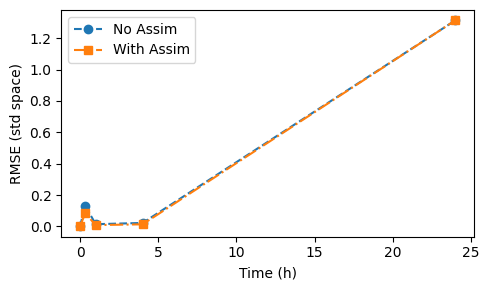

In [1]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import warnings 
warnings.filterwarnings('ignore')

ckpt_dir = "../checkpoints"
fig_dir = "../figures"
cfg_path = "../configs/default.json"

with open(cfg_path, "r") as f:
    cfg = json.load(f)

times = np.load(os.path.join(ckpt_dir, "times.npy"))
Z = np.load(os.path.join(ckpt_dir, "Z.npy"))
X_true = np.load("../" + cfg["data"]["atac_path"]).astype(np.float32)
X_true = np.log1p(np.maximum(X_true, 0.0))

import pickle
with open(os.path.join(ckpt_dir, "scaler.pkl"), "rb") as f:
    scaler = pickle.load(f)
with open(os.path.join(ckpt_dir, "pca.pkl"), "rb") as f:
    pca = pickle.load(f)

X_true_std = scaler.transform(X_true)

# Load predictions saved by predict.py
X_pred_std_noass = np.load(os.path.join(fig_dir, "X_pred_std_noass.npy"))
X_pred_std_assim = np.load(os.path.join(fig_dir, "X_pred_std_assim.npy"))

def rmse_timewise(a, b):
    return np.sqrt(((a - b) ** 2).mean(axis=1))

err_no = rmse_timewise(X_true_std, X_pred_std_noass)
err_as = rmse_timewise(X_true_std, X_pred_std_assim)

print("Times:", times)
print("Err no-assim:", err_no)
print("Err with-assim:", err_as)

# Plot RMSE vs time
os.makedirs(fig_dir, exist_ok=True)
plt.figure(figsize=(5,3))
plt.plot(times, err_no, 'o--', label='No Assim')
plt.plot(times, err_as, 's-.', label='With Assim')
plt.xlabel('Time (h)')
plt.ylabel('RMSE (std space)')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "nb_rmse_vs_time.png"), dpi=300)
plt.show()


time(h)  no-assim   with-assim   delta
  0.00    0.0001       0.0001   +0.0000
  0.33    0.1321       0.0841   +0.0480
  1.00    0.0143       0.0086   +0.0056
  4.00    0.0222       0.0134   +0.0088
 24.00    1.3135       1.3135   -0.0000


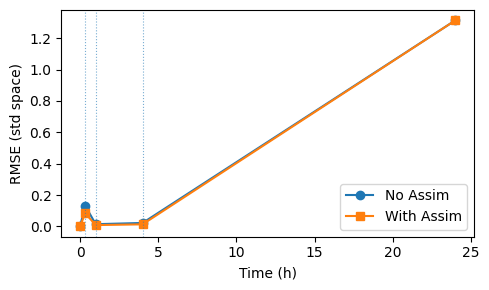

<Figure size 640x480 with 0 Axes>

In [2]:
import numpy as np
import matplotlib.pyplot as plt

err_no = np.sqrt(((X_true_std - X_pred_std_noass)**2).mean(axis=1))
err_as = np.sqrt(((X_true_std - X_pred_std_assim)**2).mean(axis=1))

print("time(h)  no-assim   with-assim   delta")
for tt, a, b in zip(times, err_no, err_as):
    print(f"{tt:6.2f}  {a:8.4f}   {b:10.4f}   {a-b:+.4f}")

plt.figure(figsize=(5,3))
plt.plot(times, err_no, 'o-', label='No Assim')
plt.plot(times, err_as, 's-', label='With Assim')
for ta in [0.33, 1.0, 4.0]:
    # vertical markers at assim times
    plt.axvline(x=ta, ls=':', lw=0.8, alpha=0.6)
plt.xlabel('Time (h)'); plt.ylabel('RMSE (std space)')
plt.legend(); plt.tight_layout(); plt.show()
plt.savefig(os.path.join(fig_dir, "nb_rmse_vs_time2.png"), dpi=300)

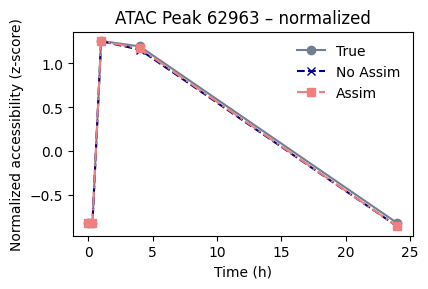

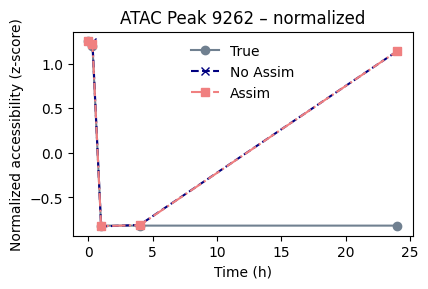

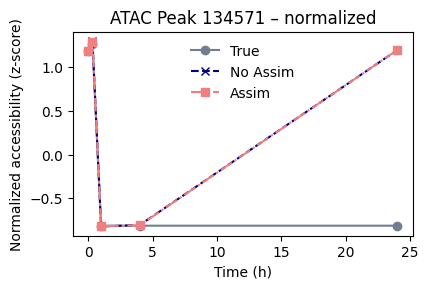

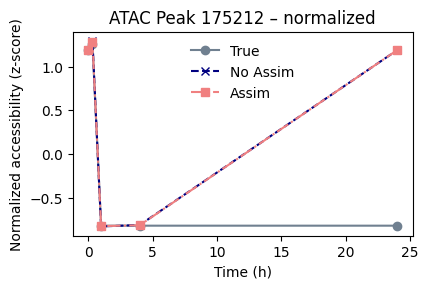

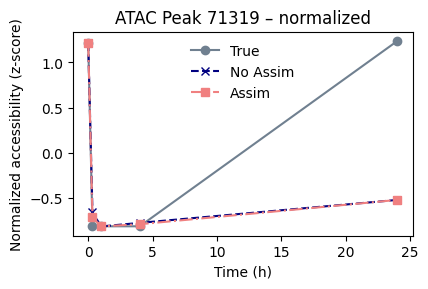

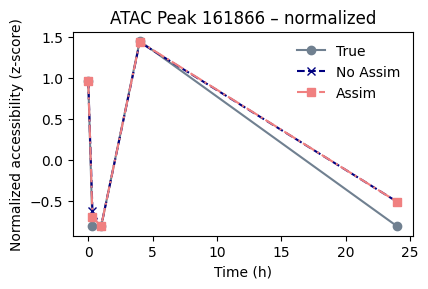

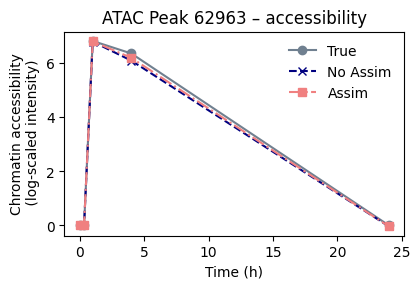

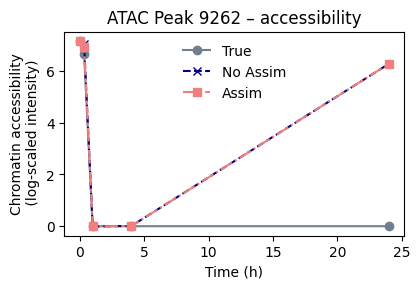

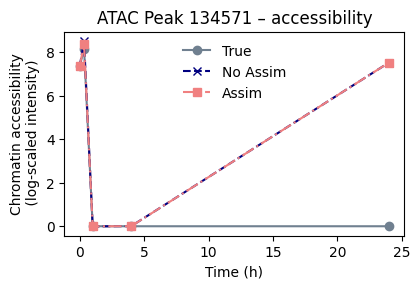

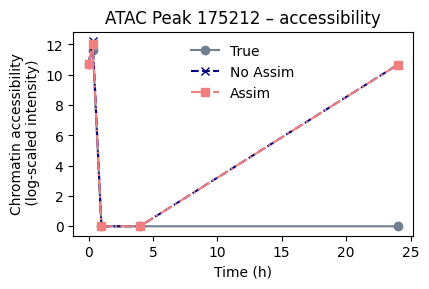

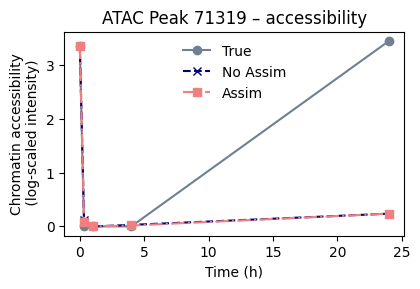

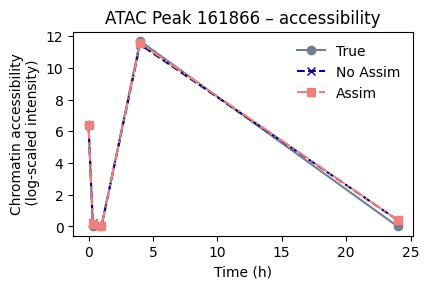

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt

colors = ['#708090', '#000080', '#F08080']

def plot_curve(y_true, y_no, y_as, times, ylabel, title, savepath):
    fig, ax = plt.subplots(figsize=(5,3))
    ax.plot(times, y_true, marker='o', color=colors[0], label='True')
    ax.plot(times, y_no, marker='x', linestyle='--', color=colors[1], label='No Assim')
    ax.plot(times, y_as, marker='s', linestyle='-.', color=colors[2], label='Assim')
    ax.set_xlabel('Time (h)')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(frameon=False)
    ax.set_box_aspect(3/5)
    fig.subplots_adjust(left=0.18, right=0.97, top=0.88, bottom=0.20)
    fig.savefig(savepath, dpi=300)
    plt.show()

var = X_true_std.var(axis=0)
idx = np.argsort(var)[-6:][::-1]

for k, p in enumerate(idx):
    plot_curve(
        y_true = X_true_std[:, p],
        y_no   = X_pred_std_noass[:, p],
        y_as   = X_pred_std_assim[:, p],
        times  = times,
        ylabel = 'Normalized accessibility (z-score)',
        title  = f"ATAC Peak {p} – normalized",
        savepath = os.path.join(fig_dir, f"atac_peak_std_{k}_{p}.png")
    )

X_true_orig = np.expm1(scaler.inverse_transform(X_true_std))
X_no_orig   = np.expm1(scaler.inverse_transform(X_pred_std_noass))
X_as_orig   = np.expm1(scaler.inverse_transform(X_pred_std_assim))

for k, p in enumerate(idx):
    plot_curve(
        y_true = X_true_orig[:, p],
        y_no   = X_no_orig[:, p],
        y_as   = X_as_orig[:, p],
        times  = times,
        ylabel = 'Chromatin accessibility\n (log-scaled intensity)',
        title  = f"ATAC Peak {p} – accessibility",
        savepath = os.path.join(fig_dir, f"atac_peak_orig_{k}_{p}.png")
    )


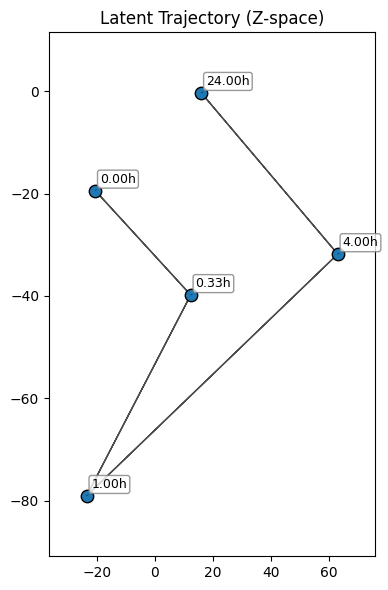

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

perp = min(3, len(Z)-1) if len(Z) > 1 else 1
emb = TSNE(n_components=2, perplexity=perp, learning_rate=50, init='pca', random_state=0).fit_transform(Z)

x, y = emb[:,0], emb[:,1]

mx, my = (x.max()-x.min())*0.15, (y.max()-y.min())*0.15
xmin, xmax = x.min()-mx, x.max()+mx
ymin, ymax = y.min()-my, y.max()+my

plt.figure(figsize=(4,6))
plt.scatter(x, y, s=80, zorder=2, edgecolors='k')

for i in range(len(Z)-1):
    dx, dy = x[i+1]-x[i], y[i+1]-y[i]
    plt.arrow(x[i], y[i], dx, dy, length_includes_head=True, head_width=0.02*max(mx,my),
              head_length=0.03*max(mx,my), alpha=0.7, zorder=1)

for i, tt in enumerate(times):
    offx = 0.015*(xmax-xmin)
    offy = 0.015*(ymax-ymin)
    px = np.clip(x[i]+offx, xmin, xmax)
    py = np.clip(y[i]+offy, ymin, ymax)
    plt.annotate(f"{tt:.2f}h",
                 xy=(x[i], y[i]), xytext=(px, py),
                 arrowprops=dict(arrowstyle='-', lw=0.5, alpha=0.6),
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.8),
                 fontsize=9)

plt.xlim(xmin, xmax); plt.ylim(ymin, ymax)
plt.title("Latent Trajectory (Z-space)")
plt.tight_layout()
plt.savefig(fig_dir + '/Latent Trajectory (Z-space)', dpi=300)
plt.show()

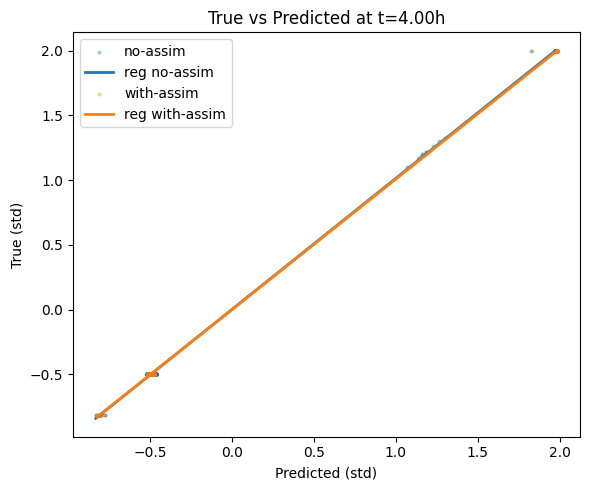

no-assim  R2: 0.9995633905537864 RMSE: 0.022177403792738914
with-assim R2: 0.9998395349888045 RMSE: 0.01344479899853468


In [5]:
import numpy as np, matplotlib.pyplot as plt

def r2_score(a, b):
    num = ((a - b)**2).sum()
    den = ((a - a.mean())**2).sum() + 1e-12
    return float(1 - num/den)

def rmse(a,b):
    return float(np.sqrt(((a-b)**2).mean()))

t_sel = 3  # 0:0h,1:0.33h,2:1h,3:4h,4:24h
N = 20000  # subsample for scatter
rng = np.random.default_rng(0)
idx = rng.choice(X_true_std.shape[1], size=min(N, X_true_std.shape[1]), replace=False)

y = X_true_std[t_sel, idx]
x_no = X_pred_std_noass[t_sel, idx]
x_as = X_pred_std_assim[t_sel, idx]

b_no = np.polyfit(x_no, y, 1); line_no = np.poly1d(b_no)
b_as = np.polyfit(x_as, y, 1); line_as = np.poly1d(b_as)

plt.figure(figsize=(6,5))
plt.scatter(x_no, y, s=4, alpha=0.3, label="no-assim")
plt.plot(np.sort(x_no), line_no(np.sort(x_no)), linewidth=2, label=f"reg no-assim")
plt.scatter(x_as, y, s=4, alpha=0.3, label="with-assim")
plt.plot(np.sort(x_as), line_as(np.sort(x_as)), linewidth=2, label=f"reg with-assim")
plt.xlabel("Predicted (std)")
plt.ylabel("True (std)")
plt.title(f"True vs Predicted at t={times[t_sel]:.2f}h")
plt.legend()
plt.tight_layout()
plt.show()

print("no-assim  R2:", r2_score(y, x_no), "RMSE:", rmse(y, x_no))
print("with-assim R2:", r2_score(y, x_as), "RMSE:", rmse(y, x_as))


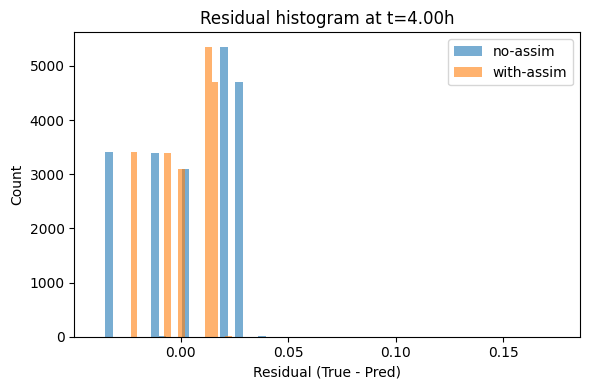

In [6]:
import numpy as np, matplotlib.pyplot as plt

res_no = y - x_no
res_as = y - x_as

plt.figure(figsize=(6,4))
plt.hist(res_no, bins=60, alpha=0.6, label="no-assim")
plt.hist(res_as, bins=60, alpha=0.6, label="with-assim")
plt.xlabel("Residual (True - Pred)")
plt.ylabel("Count")
plt.title(f"Residual histogram at t={times[t_sel]:.2f}h")
plt.legend()
plt.tight_layout()
plt.show()


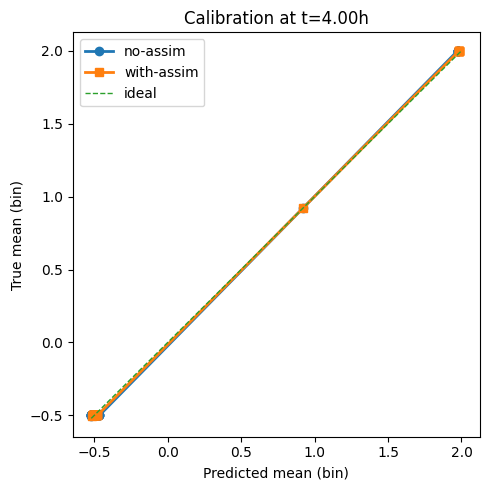

In [7]:
import numpy as np, matplotlib.pyplot as plt

def calibration_curve(true_vals, pred_vals, nbins=20):
    q = np.quantile(pred_vals, np.linspace(0,1,nbins+1))
    xs, ys = [], []
    for i in range(nbins):
        m = (pred_vals >= q[i]) & (pred_vals <= q[i+1])
        if m.sum() == 0: continue
        xs.append(pred_vals[m].mean())
        ys.append(true_vals[m].mean())
    return np.array(xs), np.array(ys)

xs_no, ys_no = calibration_curve(y, x_no, nbins=30)
xs_as, ys_as = calibration_curve(y, x_as, nbins=30)

plt.figure(figsize=(5,5))
plt.plot(xs_no, ys_no, marker='o', linewidth=2, label="no-assim")
plt.plot(xs_as, ys_as, marker='s', linewidth=2, label="with-assim")
mn = min(xs_no.min(), xs_as.min(), ys_no.min(), ys_as.min())
mx = max(xs_no.max(), xs_as.max(), ys_no.max(), ys_as.max())
plt.plot([mn,mx],[mn,mx], linestyle='--', linewidth=1, label='ideal')
plt.xlabel("Predicted mean (bin)")
plt.ylabel("True mean (bin)")
plt.title(f"Calibration at t={times[t_sel]:.2f}h")
plt.legend()
plt.tight_layout()
plt.show()


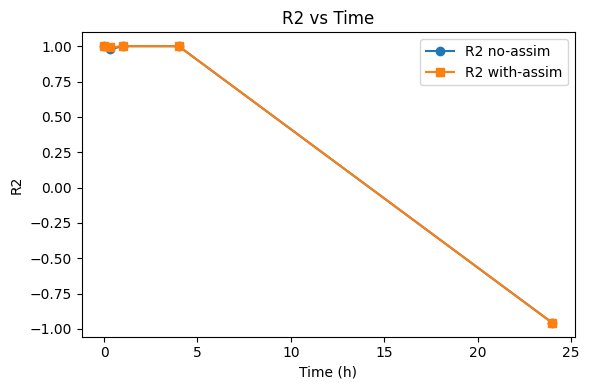

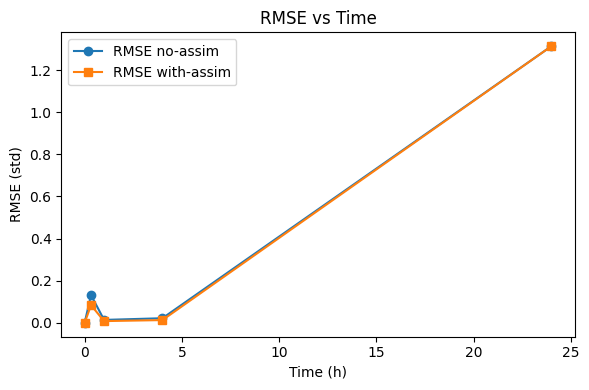

In [8]:
import numpy as np, matplotlib.pyplot as plt

def r2_axiswise(A, B):
    num = ((A - B)**2).sum(axis=1)
    den = ((A - A.mean(axis=1, keepdims=True))**2).sum(axis=1) + 1e-12
    return 1 - num/den

r2_no = r2_axiswise(X_true_std, X_pred_std_noass)
r2_as = r2_axiswise(X_true_std, X_pred_std_assim)
rmse_no = np.sqrt(((X_true_std - X_pred_std_noass)**2).mean(axis=1))
rmse_as = np.sqrt(((X_true_std - X_pred_std_assim)**2).mean(axis=1))

plt.figure(figsize=(6,4))
plt.plot(times, r2_no, marker='o', label='R2 no-assim')
plt.plot(times, r2_as, marker='s', label='R2 with-assim')
plt.xlabel("Time (h)")
plt.ylabel("R2")
plt.title("R2 vs Time")
plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(6,4))
plt.plot(times, rmse_no, marker='o', label='RMSE no-assim')
plt.plot(times, rmse_as, marker='s', label='RMSE with-assim')
plt.xlabel("Time (h)")
plt.ylabel("RMSE (std)")
plt.title("RMSE vs Time")
plt.legend(); plt.tight_layout(); plt.show()


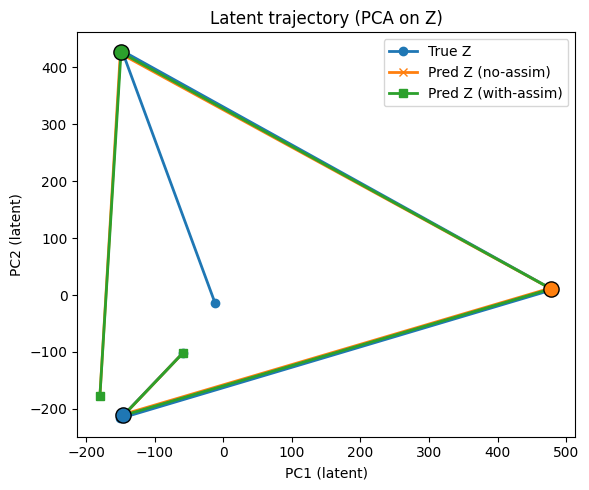

In [9]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.decomposition import PCA

Z_true = np.load(os.path.join(ckpt_dir, "Z.npy"))
Z_no = pca.transform(X_pred_std_noass)
Z_as = pca.transform(X_pred_std_assim)

Z_all = np.vstack([Z_true, Z_no, Z_as])
p2 = PCA(n_components=2, random_state=0).fit(Z_all)
T_true = p2.transform(Z_true)
T_no = p2.transform(Z_no)
T_as = p2.transform(Z_as)

assim_times = [0.33, 1.0, 4.0]
assim_idx = [np.argmin(np.abs(times - t)) for t in assim_times]

plt.figure(figsize=(6,5))
plt.plot(T_true[:,0], T_true[:,1], marker='o', linewidth=2, label='True Z')
plt.plot(T_no[:,0], T_no[:,1], marker='x', linewidth=2, label='Pred Z (no-assim)')
plt.plot(T_as[:,0], T_as[:,1], marker='s', linewidth=2, label='Pred Z (with-assim)')
for i in range(len(times)-1):
    plt.arrow(T_as[i,0], T_as[i,1], T_as[i+1,0]-T_as[i,0], T_as[i+1,1]-T_as[i,1],
              head_width=0.02, length_includes_head=True, alpha=0.6)
for ai in assim_idx:
    plt.scatter(T_as[ai,0], T_as[ai,1], s=120, edgecolor='black', zorder=5)
plt.xlabel("PC1 (latent)")
plt.ylabel("PC2 (latent)")
plt.title("Latent trajectory (PCA on Z)")
plt.legend(); plt.tight_layout(); plt.show()


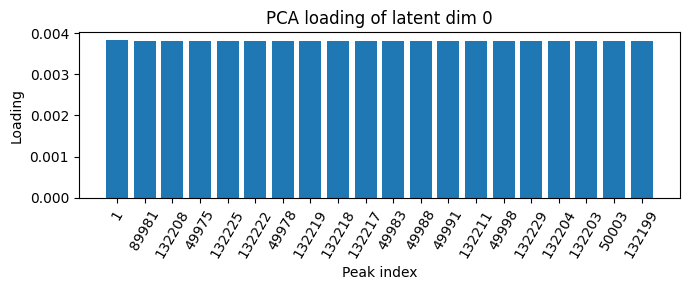

In [10]:
import numpy as np, matplotlib.pyplot as plt

W = pca.components_  # shape: (D, P)
d_sel = 0  # choose a latent dim to inspect
k = 20
idx_top = np.argsort(np.abs(W[d_sel]))[::-1][:k]
vals = W[d_sel, idx_top]

plt.figure(figsize=(7,3))
plt.bar(np.arange(k), vals)
plt.xticks(np.arange(k), [str(i) for i in idx_top], rotation=60)
plt.xlabel("Peak index")
plt.ylabel("Loading")
plt.title(f"PCA loading of latent dim {d_sel}")
plt.tight_layout(); plt.show()


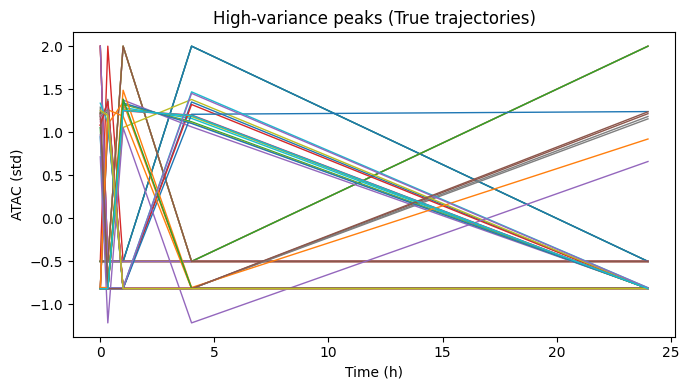

In [11]:
import numpy as np, matplotlib.pyplot as plt

var = X_true_std.var(axis=0)
top_idx = np.argsort(var)[-50:]  # many curves in one plot (subset)
plt.figure(figsize=(7,4))
for p in top_idx:
    plt.plot(times, X_true_std[:,p], linewidth=1)
plt.xlabel("Time (h)")
plt.ylabel("ATAC (std)")
plt.title("High-variance peaks (True trajectories)")
plt.tight_layout(); plt.show()


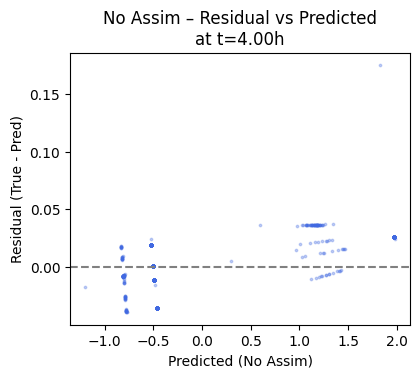

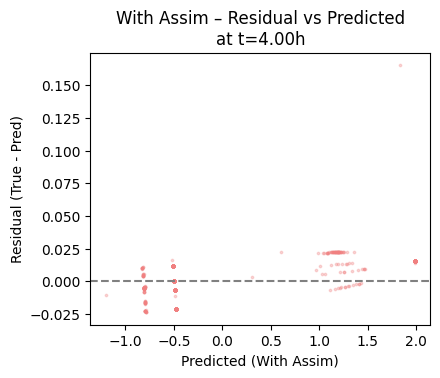

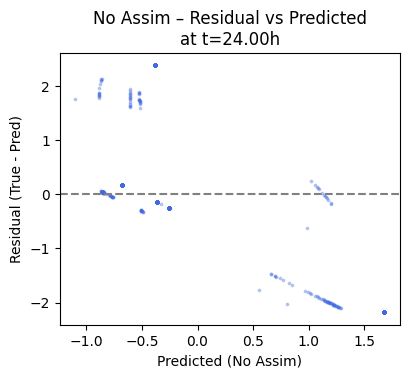

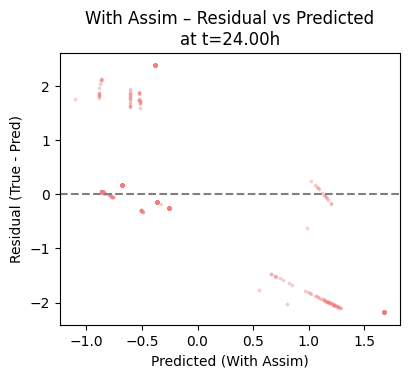

In [12]:
import matplotlib.pyplot as plt
import os
import numpy as np

t_indices = [3, 4]  
labels = ["No Assim", "With Assim"]

for t_sel in t_indices:
    res_no = X_true_std[t_sel] - X_pred_std_noass[t_sel]
    res_as = X_true_std[t_sel] - X_pred_std_assim[t_sel]
    preds_no = X_pred_std_noass[t_sel]
    preds_as = X_pred_std_assim[t_sel]

    for mode, (pred, res) in enumerate([(preds_no, res_no), (preds_as, res_as)]):
        fig, ax = plt.subplots(figsize=(5,4))
        ax.scatter(pred, res, s=3, alpha=0.3, color=['#4169E1','#F08080'][mode])
        ax.axhline(0, linestyle='--', color='gray')
        ax.set_xlabel(f"Predicted ({labels[mode]})")
        ax.set_ylabel("Residual (True - Pred)")
        ax.set_title(f"{labels[mode]} – Residual vs Predicted\nat t={times[t_sel]:.2f}h")
        ax.set_box_aspect(4/5)
        fig.subplots_adjust(left=0.18, right=0.96, top=0.88, bottom=0.20)

        fname = f"residual_vs_pred_{labels[mode].lower().replace(' ', '_')}_t{t_sel}.png"
        fig.savefig(os.path.join(fig_dir, fname), dpi=300)
        plt.show()


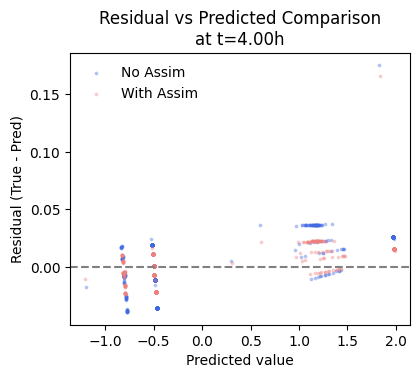

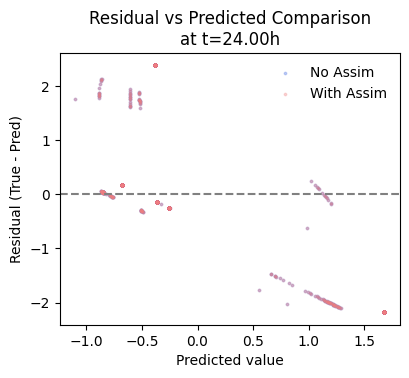

In [13]:
import matplotlib.pyplot as plt
import os
import numpy as np

t_indices = [3, 4]

for t_sel in t_indices:
    res_no = X_true_std[t_sel] - X_pred_std_noass[t_sel]
    res_as = X_true_std[t_sel] - X_pred_std_assim[t_sel]
    preds_no = X_pred_std_noass[t_sel]
    preds_as = X_pred_std_assim[t_sel]

    rmin = min(res_no.min(), res_as.min())
    rmax = max(res_no.max(), res_as.max())
    pad = 0.05 * (rmax - rmin + 1e-12)
    ylim = (rmin - pad, rmax + pad)

    fig, ax = plt.subplots(figsize=(5,4))
    ax.scatter(preds_no, res_no, s=3, alpha=0.3, color='#4169E1', label='No Assim')
    ax.scatter(preds_as, res_as, s=3, alpha=0.3, color='#F08080', label='With Assim')
    ax.axhline(0, linestyle='--', color='gray')
    ax.set_xlabel("Predicted value")
    ax.set_ylabel("Residual (True - Pred)")
    ax.set_ylim(*ylim)
    ax.set_title(f"Residual vs Predicted Comparison\nat t={times[t_sel]:.2f}h")
    ax.legend(frameon=False)
    ax.set_box_aspect(4/5)
    fig.subplots_adjust(left=0.18, right=0.96, top=0.88, bottom=0.20)
    fname = f"residual_vs_pred_comparison_t{t_sel}.png"
    fig.savefig(os.path.join(fig_dir, fname), dpi=300)
    plt.show()
